In [1]:
import sys
from pathlib import Path

scripts_dir = Path.cwd().parent / "scripts"
sys.path.insert(0, str(scripts_dir))

In [2]:
# Path to test .mrxs
path_CMU1 = r"E:\Christine\testdata\CMU-1.mrxs"
path_CMU3 = r"E:\Christine\testdata\CMU-3.mrxs"
zarr_dir = r"E:\Christine\testdata\zarr"
cache_tissue = r"E:\Christine\testdata\cache_tissue_artifact.pkl"
cache_features = r"E:\Christine\testdata\feature_summary.csv"

slides = [path_CMU1, path_CMU3]

C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\site-packages\wsidata\io\_wsi.py:157: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = read_zarr(store)


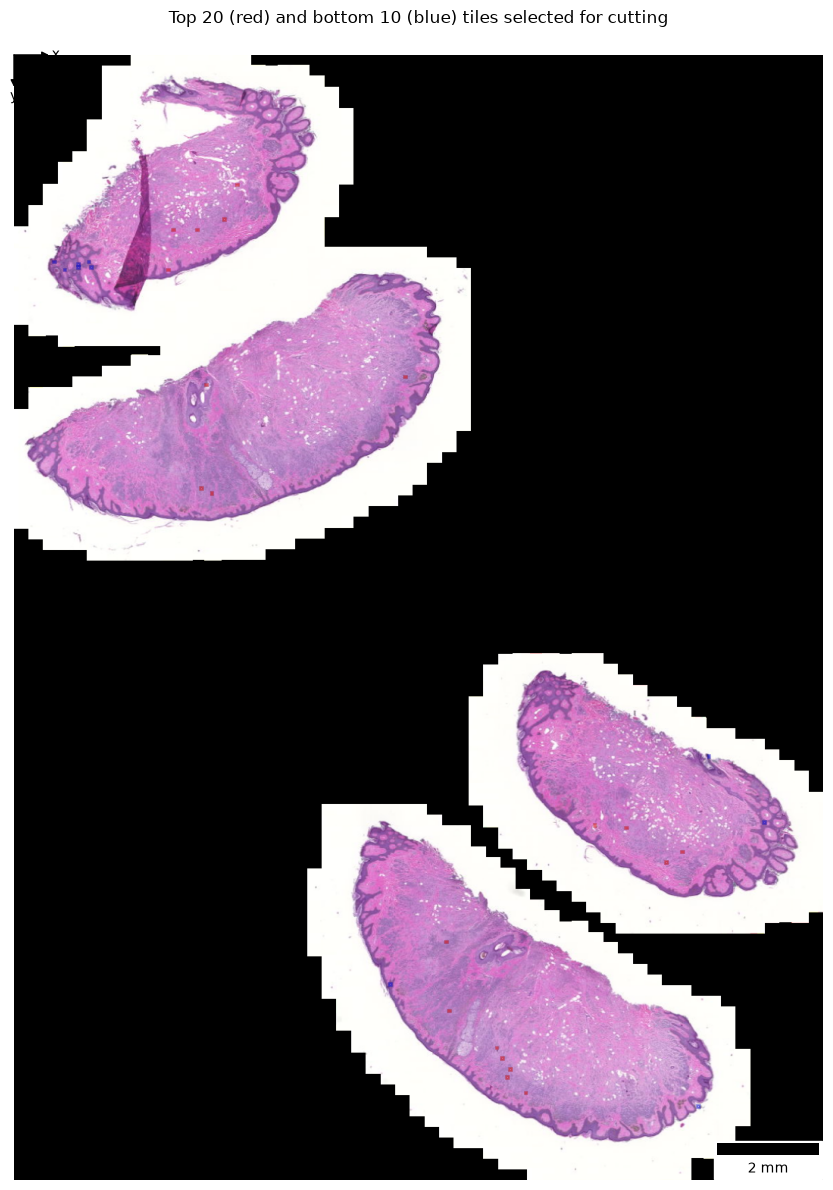

In [3]:
from roi_selection import ROISelector

abmil_path = r"E:\Christine\testdata\abmil.pt"
inference_path = r"E:\Christine\testdata\inference.pkl"

selector = ROISelector(cache_path = inference_path, slide_path = path_CMU1, top_k = 20, bottom_k = 10)
selector.tiles_to_cut()

In [4]:
sdata_lmd = selector.get_sdata_lmd()
top_polygons, bottom_polygons = selector.viewer_polygons()

In [5]:
import numpy as np
from interactive_viewer import launch_calibration_viewer

viewer, url = launch_calibration_viewer(
    slide_path=path_CMU1,
    top_polygons=top_polygons,
    bottom_polygons=bottom_polygons,
    save_json="annotations.json",
    screenshot_dir="annotation_screenshots",
    polygon_input_order="xy",
    port=5000,
    open_browser=True,
)
url

 * Serving Flask app 'interactive_viewer_5000'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


Viewer URL: http://127.0.0.1:5000
Polygon debug URL: http://127.0.0.1:5000/debug_polygons


'http://127.0.0.1:5000'

In [ ]:
sdata_lmd

In [ ]:
# Manually in Napari: 

# 1) Add calibration points (3 points, easy to locate on LMD)
# File -> new layer -> points 

# 2) Add square (to check correct placement of shapes on LMD)
# File -> new layer -> shapes

In [ ]:
# Add manually selected calibration points to sdata.points["calibration_points"]

from spatialdata.models import PointsModel
import numpy as np

points_layer = viewer.layers["calibration_points"]
image_points = points_layer.data
print(image_points)

sdata_lmd.points["calibration_points"] = PointsModel.parse(
    np.array(image_points)
)

In [ ]:
# Add square to ensure correct placement of polygons

from spatialdata.models import ShapesModel
from shapely.geometry import Polygon
import geopandas as gpd

square_layer = viewer.layers["square"]
image_square = square_layer.data
print(image_square)

polygons = [Polygon(coords) for coords in image_square]
square_gdf = gpd.GeoDataFrame(
    {"shape_id": [f"square_{i}" for i in range(len(polygons))]},
    geometry=polygons
)

sdata_lmd.shapes["square"] = ShapesModel.parse(square_gdf)

In [ ]:
sdata_lmd

In [ ]:
H = sdata_lmd.images["wsi_thumbnail"].data.shape[1]
print(H)

In [ ]:
import geopandas as gpd
from spatialdata.models import ShapesModel

def add_square_to_annotation(annotation_gdf, square_gdf):
    combined = gpd.GeoDataFrame(
        pd.concat([annotation_gdf, square_gdf], ignore_index=True),
        geometry="geometry",
        crs=annotation_gdf.crs,
    )
    return ShapesModel.parse(combined)


In [ ]:
annotation_top = add_square_to_annotation(
    sdata_lmd.shapes["top_tiles"],
    sdata_lmd.shapes["square"],
)

annotation_bottom = add_square_to_annotation(
    sdata_lmd.shapes["bottom_tiles"],
    sdata_lmd.shapes["square"],
)


In [ ]:
from dvpio.write import write_lmd
import os

lmd_dir = r"E:\Christine\testdata\lmd"

path_lmd = os.path.join(lmd_dir, "CMU1.xml")

# Transform coordinates from napari to LMD coordinate system
affine_transformation = np.array([
    [1,  0, 0],
    [0, -1, H],
    [0,  0, 1]
])

# Write LMD file with tiles and calibration points
write_lmd(
    path = path_lmd,
    annotation = annotation_top,
    calibration_points=sdata_lmd.points["calibration_points"],
    affine_transformation=affine_transformation
)